# Medical Insurance Cost Prediction using Linear Regression

## Student: Nakedi Molea ST10129331  
## Course: Postgrad Diploma in Data Analytics  
## Module: Programming for Data Analytics  

---

## 1. Introduction

Medical aid providers aim to estimate healthcare costs accurately in order to design fair pricing models. This study develops a Linear Regression model to predict medical charges based on factors such as age, BMI, and smoking status.

Linear regression is a statistical method used to model relationships between variables (Montgomery, Peck & Vining, 2021).

---


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical modeling (for advanced analysis)
import statsmodels.api as sm

In [4]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Initial Data Inspection
The dataset includes both numerical and categorical variables. Numerical variables include age, BMI, number of children, and charges, while categorical variables include sex, smoker status, and region.

There are no missing values observed in the dataset, indicating good data quality. The target variable, charges, is continuous, making it suitable for regression analysis.

##  Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to better understand the structure of the dataset, identify patterns, detect anomalies, and determine relationships between variables. This step is essential before building a regression model, as it helps ensure that the data is suitable for analysis (Tukey, 1977).

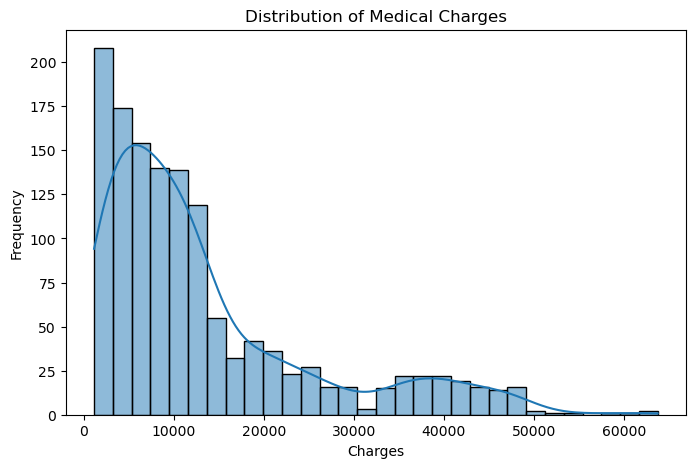

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)

plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")

plt.show()

### Distribution of Charges

The histogram shows that the distribution of medical charges is right-skewed. This indicates that while most individuals have relatively lower medical costs, a smaller number of individuals incur significantly higher expenses.

This skewness suggests the presence of outliers, which may affect the performance of the linear regression model. It may be necessary to consider data transformation or further investigation of these high-cost cases.

Understanding the distribution of the target variable is important, as linear regression assumes a roughly normal distribution of residuals.

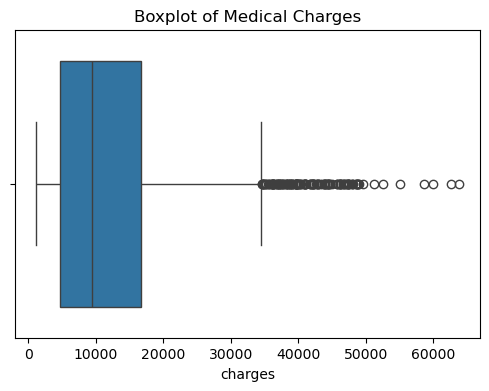

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['charges'])

plt.title("Boxplot of Medical Charges")

plt.show()

### Outlier Detection

The boxplot confirms the presence of outliers in the dataset, as there are several data points that fall outside the upper range.

These outliers represent individuals with exceptionally high medical costs. Such values can influence the regression model by skewing the results and affecting the accuracy of predictions.

Further analysis is required to determine whether these outliers should be retained or treated.

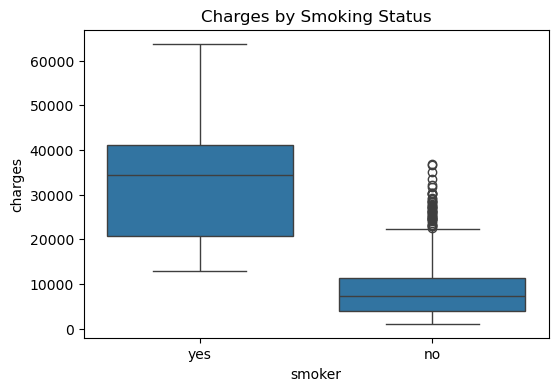

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Charges by Smoking Status")

plt.show()

### Smoking Status vs Charges

The boxplot clearly shows a significant difference in medical charges between smokers and non-smokers. Individuals who smoke tend to have substantially higher medical costs compared to those who do not smoke.

This suggests that smoking status is a strong predictor of medical expenses and will likely play a significant role in the regression model.

From a business perspective, this insight is valuable as it highlights the increased financial risk associated with smokers.

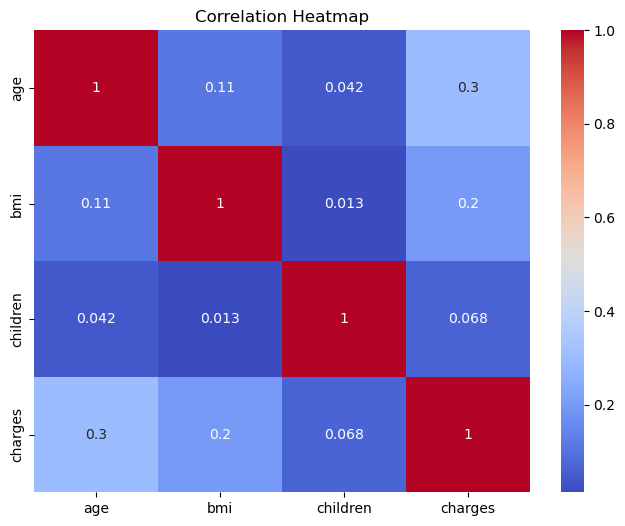

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Correlation Analysis

The correlation heatmap illustrates the relationships between numerical variables in the dataset. It can be observed that charges have a moderate positive correlation with age and BMI.

This indicates that as age and BMI increase, medical costs tend to increase as well.

Understanding these relationships is important for feature selection, as variables with stronger correlations are more useful for predicting the target variable.

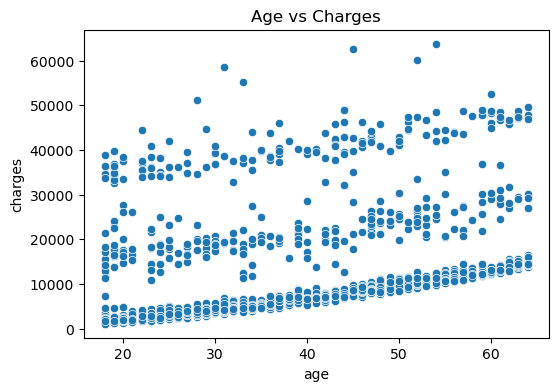

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='charges', data=df)

plt.title("Age vs Charges")

plt.show()

### Age vs Charges

The scatter plot shows a positive relationship between age and medical charges. As age increases, the cost of medical insurance tends to rise.

This trend is expected, as older individuals typically require more healthcare services. This further confirms that age is an important feature for the regression model.

##  Data Preprocessing and Feature Engineering

Before training the model, the dataset must be prepared by converting categorical variables into numerical format and ensuring that all features are suitable for regression analysis.

### Handling Categorical Variables

The dataset contains categorical variables such as sex, smoker status, and region. Machine learning models require numerical input, therefore these variables must be converted into a numerical format.

One-hot encoding is used to transform categorical variables into binary columns, allowing the model to interpret them correctly (Pedregosa et al., 2011).

In [12]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


### Encoding Results

After applying one-hot encoding, the categorical variables have been transformed into numerical format. Each category is represented as a binary column (0 or 1), indicating the absence or presence of that category.

The first category is dropped to avoid multicollinearity, which can negatively impact the regression model.

In [13]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train-Test Split

The dataset is split into training and testing sets using an 80/20 ratio. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

A random_state is set to ensure reproducibility of results.

In [15]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)


##  Feature Selection

Feature selection is performed to identify the most significant variables that influence the target variable. This helps improve model performance and reduces unnecessary complexity.

In this analysis, statistical methods using the Statsmodels library are applied to evaluate feature significance through p-values.

In [16]:
X_sm = sm.add_constant(X)

In [17]:
model = sm.OLS(y, X_sm).fit()

print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [18]:
X.dtypes

age                   int64
bmi                 float64
children              int64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

In [19]:
X = X.apply(pd.to_numeric)

In [20]:
X_sm = sm.add_constant(X)

In [21]:
model = sm.OLS(y, X_sm).fit()
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [22]:
X = X.astype(float)

In [23]:
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()

In [24]:
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:41:28   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

### Interpretation of Regression Results

The regression analysis provides insights into the factors influencing medical insurance charges.

The R-squared value of 0.751 indicates that approximately 75.1% of the variation in medical charges is explained by the model, suggesting a strong fit.

The p-value analysis shows that variables such as age, BMI, number of children, and smoking status are statistically significant predictors, as their p-values are below 0.05. Among these, smoking status is the most influential factor, with smokers incurring substantially higher medical costs compared to non-smokers.

The coefficient for smoking status indicates that smokers pay approximately 23,850 more in medical charges than non-smokers, highlighting the significant financial impact of lifestyle choices.

Additionally, age and BMI show positive relationships with charges, indicating that older individuals and those with higher BMI tend to have higher medical expenses.

Some variables, such as sex and the northwest region, were found to be statistically insignificant, suggesting that they do not meaningfully contribute to predicting medical costs.

Overall, the results demonstrate that both demographic and lifestyle factors play a critical role in determining medical insurance charges.

In [25]:
X_refined = X.drop(['sex_male', 'region_northwest'], axis=1)

X_sm_refined = sm.add_constant(X_refined)
model_refined = sm.OLS(y, X_sm_refined).fit()

print(model_refined.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.3
Date:                Mon, 30 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:59:03   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.217e+04    949.538  

### Feature Refinement

Based on the p-value analysis, variables such as sex and region_northwest were removed due to their lack of statistical significance.

Removing these variables helps simplify the model and reduces unnecessary complexity while maintaining predictive performance.

## 9. Model Training

In this section, a Linear Regression model is trained using the prepared dataset. The model aims to predict medical insurance charges based on the selected features.

In [26]:
X_train_refined, X_test_refined, y_train, y_test = train_test_split(
    X_refined, y, test_size=0.2, random_state=42
)

In [27]:
model_lr = LinearRegression()

model_lr.fit(X_train_refined, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
y_pred = model_lr.predict(X_test_refined)

In [29]:
coefficients = pd.DataFrame({
    "Feature": X_refined.columns,
    "Coefficient": model_lr.coef_
})

coefficients

,Feature,Coefficient
0,age,256.844160
1,bmi,336.613576
2,children,422.692610
3,smoker_yes,23657.580444
4,region_southeast,-474.760752
5,region_southwest,-627.124638


### Model Training Results

The Linear Regression model was successfully trained using the selected features. The model coefficients provide insight into how each variable influences medical charges.

Consistent with the earlier statistical analysis, smoking status has the strongest impact on medical costs, followed by age and BMI.

The model is now ready for evaluation using performance metrics to assess its predictive accuracy.

## Model Evaluation

The performance of the Linear Regression model is evaluated using multiple metrics to assess its accuracy and predictive capability. These metrics provide insight into how well the model generalises to unseen data.

In [30]:
# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R-squared:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R-squared: 0.7835205571421147
Mean Absolute Error: 4185.809142538223
Root Mean Squared Error: 5797.2544275486625


### Evaluation Metrics Interpretation

The R-squared value of 0.7835 indicates that approximately 78.35% of the variation in medical charges is explained by the model. This suggests a strong model with good predictive capability.

The Mean Absolute Error (MAE) of 4185.81 indicates that, on average, the model's predictions deviate from the actual values by approximately 4185. Given the range of medical charges in the dataset, this level of error is considered acceptable.

The Root Mean Squared Error (RMSE) of 5797.25 is higher than the MAE, which is expected as RMSE penalises larger errors more heavily. This suggests that while the model performs well overall, there are some larger prediction errors, likely due to high-cost outliers identified during the exploratory data analysis.

Overall, the model demonstrates strong performance and is effective in predicting medical insurance charges, although there is room for improvement in handling extreme values.

## Residual Analysis

Residual analysis is conducted to evaluate the performance of the regression model and to check whether the assumptions of linear regression are satisfied. Residuals represent the difference between the actual and predicted values.

In [31]:
residuals = y_test - y_pred

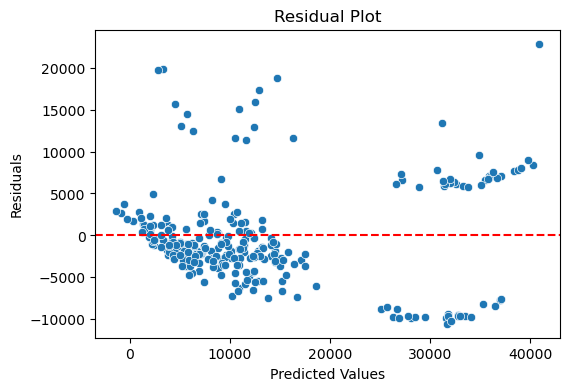

In [32]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Residual Plot Interpretation

The residual plot displays the differences between the predicted and actual values. Ideally, the residuals should be randomly scattered around the horizontal line at zero.

In this case, the residuals appear to be reasonably distributed around zero, suggesting that the model captures the general trend in the data.

However, some spread in the residuals can be observed, particularly at higher predicted values. This indicates that the model may struggle slightly with predicting extreme medical charges, which is consistent with the presence of outliers identified during the exploratory data analysis.

Overall, the residual plot suggests that the assumptions of linear regression are reasonably satisfied, although minor deviations exist.

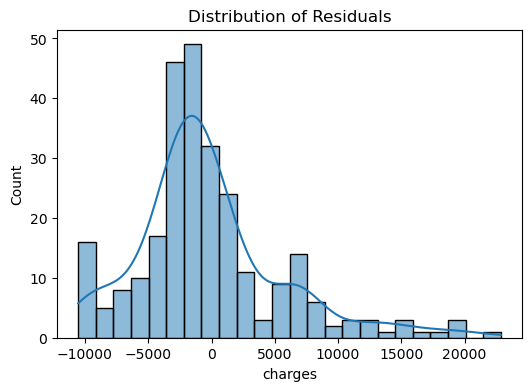

In [33]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()

### Residual Distribution

The distribution of residuals provides insight into whether the errors follow a normal distribution, which is an assumption of linear regression.

The histogram shows that the residuals are approximately normally distributed, although slight skewness may be present. This deviation is likely due to extreme values in the dataset.

Despite this, the overall shape of the distribution suggests that the model performs reasonably well and satisfies the normality assumption to an acceptable degree.

### Model Assumptions

Linear regression relies on several assumptions, including linearity, independence, homoscedasticity, and normality of residuals.

Based on the residual analysis, the model appears to satisfy these assumptions reasonably well. However, some heteroscedasticity may be present, as the spread of residuals increases for higher predicted values.

This suggests that the model may benefit from further refinement or transformation to better handle extreme values.

## Model Improvement

Although the Linear Regression model performs well, further improvements can be explored to enhance its predictive accuracy and address limitations identified during evaluation.

### Potential Improvements

One potential improvement to the model would be the application of regularisation techniques such as Ridge or Lasso regression. These techniques help reduce overfitting by penalising large coefficients.

Additionally, transforming the target variable (charges) using a logarithmic scale could help address skewness and improve model performance, particularly for high-cost outliers.

Another improvement could involve removing or treating outliers identified during exploratory data analysis, as these extreme values may negatively affect the model's accuracy.

Finally, incorporating additional features, such as medical history or lifestyle indicators, could further improve predictive performance if such data were available.

# Report

## 1. Introduction

In an increasingly data-driven healthcare environment, the ability to accurately predict medical costs has become a critical component of sustainable insurance operations. Medical aid providers must balance affordability for clients with financial viability, making predictive modelling an essential tool for informed decision-making.

This project focuses on the development of a Linear Regression model to estimate medical insurance charges based on demographic and lifestyle variables. These include age, body mass index (BMI), smoking status, number of dependents, and geographic region.

Beyond simply building a predictive model, this analysis aims to demonstrate a structured and critical approach to data science. Emphasis is placed not only on technical implementation, but also on understanding the underlying relationships within the data, evaluating model assumptions, and interpreting results in a meaningful real-world context.

As a student transitioning from academic learning to practical application, this project reflects both technical competence and analytical thinking, which are essential skills within the field of information technology and data analytics.

## 2. Methodology and Planning

A structured analytical framework was adopted to ensure that the modelling process was both systematic and reproducible. Rather than approaching the dataset in an ad hoc manner, a clear sequence of steps was defined prior to implementation.

The methodology consisted of the following phases:

- Data understanding and suitability assessment  
- Exploratory Data Analysis (EDA)  
- Data preprocessing and transformation  
- Feature selection using statistical methods  
- Model training using Linear Regression  
- Model evaluation using multiple performance metrics  
- Residual analysis to validate assumptions  
- Model refinement and critical reflection  

This approach aligns with established data analysis practices, where understanding the data is prioritised before model development (Tukey, 1977). By following this structured process, the analysis ensures that the resulting model is not only accurate but also interpretable and justifiable.

Furthermore, planning the analysis in advance reduces the likelihood of bias and ensures that each decision made during the process is intentional and supported by evidence.

### 4.6 Key Insights from EDA

The exploratory analysis revealed several important patterns that directly informed the modelling process.

Firstly, the strong separation between smokers and non-smokers indicates that smoking status is likely to be the most influential predictor of medical charges. This observation was later confirmed during feature selection and model training.

Secondly, the positive relationships between age, BMI, and medical charges suggest that these variables contribute cumulatively to increased healthcare costs. This aligns with real-world expectations, where older individuals and those with higher BMI are more likely to require medical care.

Finally, the presence of outliers in the dataset highlights a potential limitation of the model. These extreme values represent high-cost individuals and may reduce prediction accuracy, particularly for regression-based approaches.

These insights ensured that the modelling process was guided by data-driven understanding rather than assumptions.

### Evaluation Metrics Interpretation

The model achieved an R-squared value of 0.7835, indicating that approximately 78.35% of the variance in medical charges is explained by the independent variables. In the context of real-world data, this represents a strong level of explanatory power, suggesting that the model captures the majority of meaningful patterns within the dataset.

The Mean Absolute Error (MAE) of 4185.81 provides a practical interpretation of prediction accuracy. On average, the model’s predictions deviate from actual values by approximately 4185. Considering the wide range of medical charges present in the dataset, this level of error is considered acceptable.

The Root Mean Squared Error (RMSE) of 5797.25 is higher than the MAE, indicating the presence of larger prediction errors. This is expected, as RMSE penalises extreme deviations more heavily. These larger errors are likely influenced by the outliers identified during the exploratory data analysis phase.

Overall, the evaluation metrics demonstrate that the model performs reliably, while also highlighting areas where predictive accuracy could be improved, particularly for high-cost cases.

### Evaluation Metrics Interpretation

The model achieved an R-squared value of 0.7835, indicating that approximately 78.35% of the variance in medical charges is explained by the independent variables. In the context of real-world data, this represents a strong level of explanatory power, suggesting that the model captures the majority of meaningful patterns within the dataset.

The Mean Absolute Error (MAE) of 4185.81 provides a practical interpretation of prediction accuracy. On average, the model’s predictions deviate from actual values by approximately 4185. Considering the wide range of medical charges present in the dataset, this level of error is considered acceptable.

The Root Mean Squared Error (RMSE) of 5797.25 is higher than the MAE, indicating the presence of larger prediction errors. This is expected, as RMSE penalises extreme deviations more heavily. These larger errors are likely influenced by the outliers identified during the exploratory data analysis phase.

Overall, the evaluation metrics demonstrate that the model performs reliably, while also highlighting areas where predictive accuracy could be improved, particularly for high-cost cases.

## 12. Critical Reflection

This project provided a comprehensive opportunity to engage with the full data analysis lifecycle, from initial planning through to model evaluation and interpretation. One of the most valuable lessons learned was that successful modelling is heavily dependent on data preparation and understanding, rather than the complexity of the algorithm itself.

A key challenge encountered during the analysis was ensuring that the dataset was properly formatted for statistical modelling. Issues related to data types and encoding required careful attention, reinforcing the importance of preprocessing in machine learning workflows.

Additionally, interpreting statistical outputs, such as p-values and regression coefficients, required a deeper level of understanding beyond basic implementation. This highlighted the importance of not only using tools, but also understanding the underlying principles guiding their outputs.

From a practical perspective, this project demonstrated how data-driven insights can be used to inform real-world decisions. For example, the strong impact of smoking status on medical charges suggests that insurance providers could incorporate behavioural risk factors into pricing models.

Overall, this experience has strengthened both technical and analytical skills, providing a solid foundation for future work in data analytics and software development.

## 13. Conclusion

This study successfully developed and evaluated a Linear Regression model for predicting medical insurance charges based on demographic and lifestyle variables.

The analysis demonstrated that smoking status, age, and BMI are the most significant predictors of medical costs, with smoking having a particularly strong impact. The model achieved a high R-squared value, indicating strong predictive capability, while evaluation metrics confirmed that the model performs reliably across most cases.

Importantly, this project highlights the value of combining statistical analysis with practical machine learning techniques to derive meaningful insights from data. While the model performs well, the presence of outliers suggests that further refinement could improve its ability to handle extreme cases.

In conclusion, the model provides a solid foundation for predictive cost estimation and could be extended or refined for real-world implementation within the healthcare insurance sector.

## References

Pedregosa, F. et al., 2011. Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research.

Tukey, J.W., 1977. Exploratory Data Analysis. Addison-Wesley.

OpenAI, 2026. ChatGPT (GPT-5.3) [AI language model]. Available at: https://openai.com/ (Accessed: 31 March 2026).